**Authors**: Firas Abouzahr (Northwestern), Sara Sussman (Fermilab)

# Background reading on CEM for cQED
The computational-electromagnetics (CEM) methods underlying these simulations — FEM discretization, meshing, eigenvalue solvers, and the multiscale challenges specific to superconducting devices — are reviewed in:
* [Elkin et al.](https://arxiv.org/abs/2511.20774), *Opportunities and Challenges of Computational Electromagnetics Methods for Superconducting Circuit Quantum Device Modeling: A Practical Review*, arXiv:2511.20774 (2025).

We point to specific sections of this review inline below.

# Driven simulations for superconducting circuits

## What are driven simulations?

Driven simulations solve for the electromagnetic response of a structure to an applied excitation over a range of frequencies. Rather than finding the natural modes of a device, they compute the steady-state electric and magnetic fields produced by a driven source (e.g., a lumped port) as a function of frequency. This is governed by the frequency-domain wave equation. For nonmagnetic media ($\mu_r = 1$, as assumed throughout for these dielectrics and superconductors) this reads

$$\nabla \times (\nabla \times \mathbf{E}) - \left(\frac{\omega}{c}\right)^2 \epsilon_r \mathbf{E} = -i\omega\mu_0 \mathbf{J},$$

which is the general curl–curl form $\nabla \times \mu_r^{-1}\nabla \times \mathbf{E} - k_0^2\,\epsilon_r\,\mathbf{E} = -ik_0\eta_0\,\mathbf{J}$ specialized to $\mu_r = 1$ ($k_0 = \omega/c$ is the free-space wavenumber, $\eta_0 = \sqrt{\mu_0/\epsilon_0}$, and $k_0\eta_0 = \omega\mu_0$); see [Elkin et al., arXiv:2511.20774 (2025)](https://arxiv.org/abs/2511.20774), Eq. (8). It is the source-free eigenmode wave equation ([Elkin et al., arXiv:2511.20774 (2025)](https://arxiv.org/abs/2511.20774), Eq. (33)) with the source term restored. Here $\mathbf{J}$ is the source current density.



## Why driven simulations?

Driven simulations compute quantities such as scattering parameters ($S$-parameters), port impedances, and field distributions.

For superconducting circuits, driven simulations are commonly used to characterize feedlines, couplers, and resonators. They can be used to determine resonator frequencies and linewidths, extract external coupling rates ($\kappa_\text{ext}$), and study how microwave signals propagate through a device. The port impedances and scattering parameters they return are also the starting point for impedance-based ("black-box") quantization, in which a device's multi-port network parameters are mapped onto circuit Hamiltonian parameters ([Elkin et al., arXiv:2511.20774 (2025)](https://arxiv.org/abs/2511.20774), Sec. I). Because driven simulations explicitly model microwave excitation and readout through ports, they typically provide the most direct comparison to experimental $S$-parameter measurements.

## Time domain versus frequency domain
Electromagnetic simulations can be performed in either the time domain or frequency domain. Time-domain solvers compute how electromagnetic fields evolve in time after an excitation, while frequency-domain solvers compute the response of a structure at a particular angular frequency, $\omega$.

Palace supports both approaches. Time-domain simulations are useful for studying transient phenomena, such as pulse propagation, switching behavior, or resonator ringdown. Frequency-domain simulations are useful for studying steady-state quantities such as resonant frequencies, quality factors, coupling rates, and scattering parameters.

In this tutorial, we will focus on frequency-domain simulations.

# Driven simulation of a resonator and fitting to resonator lineshape

## Feedline–resonator device

For this tutorial, we simulate a CPW feedline coupled to a meander resonator — a simplified readout geometry inspired by the coupled transmon–resonator layout in the [eigenmode tutorial](eigenmode_EPR.ipynb).

### <u>Placing lumped ports for driven simulations?</u>

Lumped ports need to be placed such that they bridge the driven CPW (e.g., the feedline for our examples) to ground. The port resistance should match the characteristic impedance of the feedline (50 $\Omega$ here, set by R=50 in the boundary cell below). A port whose resistance equals the feedline impedance absorbs the incident wave instead of sending part of it back into the device. This keeps the simulated $S_{21}$ a clean measure of the resonator response, without the standing-wave ripple a mismatched port would add.

[Here](https://www.comsol.com/blogs/modeling-coplanar-waveguides) is a great guide from COMSOL that illustrates good practices for placing lumped ports.

In [1]:
# Run Quantum Metal headless so the notebook renders inline and never needs a
# display (works in JupyterLab, Docker, CI, or any headless machine). These are
# set with setdefault, so the container's own settings still take precedence.
import os
os.environ.setdefault("QISKIT_METAL_HEADLESS", "1")
os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")
os.environ.setdefault("MPLBACKEND", "Agg")

import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import Dict, Headings
from qiskit_metal import MetalGUI

from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight

In [2]:
design = designs.DesignPlanar({}, overwrite_enabled=True)
design.delete_all_components()
gui = MetalGUI(design)

um = 1e-3  # Qiskit Metal default units are mm

# Chip
design.chips.main.size.size_x = '6mm'
design.chips.main.size.size_y = '4mm'
design.chips.main.size.size_z = '-280um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '-1mm'

# Use default-ish CPW values
design.variables['cpw_width'] = '10um'
design.variables['cpw_gap'] = '6um'

# Feedline
x1 = -2.5
x2 =  2.5
y_feed = 0.0

# skipping creating launch pads for this example - we will put the lumped ports directly on the feedline. 
LP1 = OpenToGround(design, 'LP1', options=dict(chip='main', pos_x=f'{x1}mm', pos_y=f'{y_feed}mm', orientation=180, width='10um', gap='6um'))
LP2 = OpenToGround(design, 'LP2', options=dict(chip='main', pos_x=f'{x2}mm', pos_y=f'{y_feed}mm', orientation=0, width='10um', gap='6um'))

feedline = RouteStraight(
    design, 'feedline',
    options=dict(
        pin_inputs=dict(
            start_pin=dict(component='LP1', pin='open'),
            end_pin=dict(component='LP2', pin='open'),
        ),
        trace_width='10um',
        trace_gap='6um',
    )
)

# resonator options
res_y_top = -30*um
res_y_bot = -1.7
res_x_top = -0.35
res_x_bot =  0.35

res_start = OpenToGround(design, 'res_start', options=dict(chip='main', pos_x=f'{res_x_top}mm', pos_y=f'{res_y_top}mm', orientation=180, width='10um', gap='6um'))
res_end = OpenToGround(design, 'res_end', options=dict(chip='main', pos_x=f'{res_x_bot}mm', pos_y=f'{res_y_bot}mm', orientation=180, width='10um', gap='6um'))

# resonator 
resonator = RouteMeander(
    design,
    'resonator',
    Dict(
        trace_width='10um',
        trace_gap='6um',
        total_length='8.6mm',
        hfss_wire_bonds=False,
        fillet='80um',
        lead=dict(start_straight='150um'),
        meander=dict(spacing='0.25mm'),
        pin_inputs=Dict(
            start_pin=Dict(component='res_start', pin='open'),
            end_pin=Dict(component='res_end', pin='open')
        ),
    )
)

gui.rebuild()

## create lumped ports
trace_w = 10*um
gap = 6*um

port_width = 30*um   # instead of trace_w
port_height = gap

x_port1 = x1 + 100*um
x_port2 = x2 - 100*um
y_port = y_feed + trace_w/2 + gap/2

feedline_port1 = draw.rectangle(port_width, port_height, x_port1, y_port)
design.qgeometry.add_qgeometry("poly", LP1.id, {"feedline_port1": feedline_port1}, layer=1, subtract=False)

feedline_port2 = draw.rectangle(port_width, port_height, x_port2, y_port)
design.qgeometry.add_qgeometry("poly", LP2.id, {"feedline_port2": feedline_port2}, layer=1, subtract=False)

gui.refresh()
gui.autoscale()

08:40PM 22s WARNING [_qt_message_handler]: WARNING: Populating font family aliases took 57 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost.  (No context available from Qt)
Python Traceback (most recent call last):
  File "/Users/firasabouzahr/miniforge3/envs/QDW26/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3225, in _run_cell
    result = runner(coro)
  File "/Users/firasabouzahr/miniforge3/envs/QDW26/lib/python3.11/site-packages/IPython/core/async_helpers.py", line 128, in _pseudo_sync_runner
    coro.send(None)
  File "/Users/firasabouzahr/miniforge3/envs/QDW26/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3447, in run_cell_async
    has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
  File "/Users/firasabouzahr/miniforge3/envs/QDW26/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3688, in run_ast_nodes
    if await self.run_code(code, result, async_=asy):
  

# Mesh Quantum Metal design with pyPalace (Gmsh backend)

In Palace, mesh attributes provide the labels used to specify entries in `config["Domains"]` (volume regions or related postprocessing) and `config["Boundaries"]` (surface regions where we apply boundary conditions or related postprocessing).

pyPalace leaves it up to the user to define which Quantum Metal surfaces we want to give mesh attributes for full flexibility. Volumes (substrate & air box), the far field, and the ground plane are automatically assigned mesh attributes. Let's take a look at our Quantum Metal design surfaces table:

In [3]:
from pypalace import mesh

In [4]:
surface_table = mesh.get_quantum_metal_surfaces(design)
surface_table

,component_id,component_name,name,subtract
0,1,LP1,open_to_ground,True
1,2,LP2,open_to_ground,True
2,4,res_start,open_to_ground,True
3,5,res_end,open_to_ground,True
4,1,LP1,feedline_port1,False
5,2,LP2,feedline_port2,False
6,3,feedline,trace,False
7,3,feedline,cut,True
8,6,resonator,trace,False
9,6,resonator,cut,True


Polygons with ```subtract == True``` are the designs' metal (superconducting thin-film) components, while polygons with ```subtract == False``` are etched regions. We will want to give all metal components some boundary condition, so we need to give all of these mesh attributes. 

For interface dielectric losses (boundaries postprocessing), we would also want to assign etched regions mesh attributes as well. For this example, we will skip this. 

In [5]:
# each dictionary component has entry component ID, name, mesh attribute ID we want to assign it
attributes = {}

# this loop is simply assigning every metal component in our design a mesh attribute
mesh_num = 1
for row in range(len(surface_table)):
    this_component = surface_table.iloc[row]
    if this_component["subtract"] == False:
        name = this_component["name"]
        comp_id = this_component["component_id"]
        attributes[(comp_id,name)] = mesh_num
        mesh_num += 1 # cannot repeat mesh IDs or Palace will fail

attributes # each dictionary entry follows: (<component ID number>, <surface name>): <mesh attribute number> 

{(1, 'feedline_port1'): 1,
 (2, 'feedline_port2'): 2,
 (3, 'trace'): 3,
 (6, 'trace'): 4}

## Mesh the design

now that we have defined a dictionary for the Quantum Metal surfaces we want to give boundary conditions, we can actually mesh our design:

In [6]:
mesh_dir = "mesh/"
meshfile = "driven_resonator.msh"
path_to_mesh = mesh_dir + meshfile

## mesh the design --> returns pandas.dataframe of labeled mesh attributes ##
## look at readthedocs, mesh_Quantum_Metal_design has a lot of flexibility to control surface mesh size, volume mesh size, substrate size, etc ## 
attributes_table = mesh.mesh_Quantum_Metal_design(design,
                                                  output_mesh=path_to_mesh,
                                                  Attributes=attributes);

Info    : Meshing 1D...                                                                                                                   
Info    : [  0%] Meshing curve 41 (Line)
Info    : [ 10%] Meshing curve 42 (Line)
Info    : [ 10%] Meshing curve 43 (Line)
Info    : [ 10%] Meshing curve 44 (Line)
Info    : [ 10%] Meshing curve 45 (Line)
Info    : [ 10%] Meshing curve 46 (Line)
Info    : [ 10%] Meshing curve 47 (Line)
Info    : [ 10%] Meshing curve 48 (Line)
Info    : [ 10%] Meshing curve 49 (Line)
Info    : [ 10%] Meshing curve 51 (Line)
Info    : [ 10%] Meshing curve 412 (Line)
Info    : [ 10%] Meshing curve 413 (Line)
Info    : [ 10%] Meshing curve 414 (Line)
Info    : [ 10%] Meshing curve 415 (Line)
Info    : [ 10%] Meshing curve 416 (Line)
Info    : [ 10%] Meshing curve 417 (Line)
Info    : [ 10%] Meshing curve 418 (Line)
Info    : [ 10%] Meshing curve 419 (Line)
Info    : [ 10%] Meshing curve 420 (Line)
Info    : [ 10%] Meshing curve 421 (Line)
Info    : [ 10%] Meshing curve 

```pypalace.mesh.mesh_Quantum_Metal_design``` returns an ordered dataframe of the mesh components. We will use these to build our Palace configuration file. Notice this function automatically makes a ground plane, an air box, a substrate box, and the far field. 

In [7]:
attributes_table

,Name,ID,Type
0,1__feedline_port1,1,Surface
1,2__feedline_port2,2,Surface
2,3__trace,3,Surface
3,6__trace,4,Surface
6,substrate,5,Volume
7,air,6,Volume
4,ground_plane,7,Surface
5,far_field,8,Surface


# Build Palace configuration file with pyPalace

pyPalace follows the Palace configuration schema one-to-one. In this sense, the pyPalace configuration building using `pypalace.Config` and `pypalace.builder` follows directly from the [Palace config documentation](https://awslabs.github.io/palace/stable/config/config/).

In [8]:
from pypalace import Config
from pypalace.builder import Model, Domains, Boundaries, Solver  # these match one-to-one with Palace config syntax

In [9]:
''' choose path & name for Palace configuration file we will build below '''
config_dir = "config/"
path_to_config = config_dir + "driven_resonator.json"

## Initialize pyPalace Config object:

In [10]:
driven_config = Config(path_to_config)

## Add `config["Problems"]` and `config["Model"]`

In [11]:
driven_config.add_Problem(Type="Driven",
                             Output="../assets/driven_output")

# don't use here but this is how we could add adaptive mesh refinement
#AMR = Model.Refinement(Tol = 1e-6,MaxIts = 3)

# define config["Model"] block
driven_config.add_Model(Mesh = path_to_mesh, # point to our meshfile
                    L0 = 1e-6,# mesh units relative to meters
                    #Refinement=AMR
                    ) 

## Add `config["Domains"]`

Used to define properties and postprocessing for meshed volumes.

The substrate below is given a permittivity and a small bulk loss tangent, while the metals are treated as PEC (Boundaries cell). The bulk loss tangent and the external ports are therefore the only loss channels in this model. The interface dielectric loss (metal-air, metal-substrate, substrate-air) and conductor loss that usually dominate at cryogenic temperatures are not included (see the earlier Eigenmode EPR notebook to learn more about those interface losses). This is why the simulation is well suited to extracting the external coupling rate $\kappa_\text{ext}$, but is not set up to predict a realistic internal rate $\kappa_\text{int}$.

In [12]:
# from the attribute table above:
substrate_id = 5
airbox_id = 6

# define materials
silicon = Domains.Material(Attributes = [substrate_id], # attributes to give the properties below to:
                                     Permeability=1.0, # magnetic permeability
                                     Permittivity=11.45, # electric permittivity
                                     LossTan=1e-07) # bulk loss tangent

airbox = Domains.Material([airbox_id],1.0,1.0,0.0)

# will not use this here but an example of adding domain postprocessing:


materials = [silicon,airbox] # material list for input into add_Domains()
driven_config.add_Domains(Materials = materials) # add materials to our configuration file

## Add `config["Boundaries"]`

Used to define boundary conditions and postprocessing for meshed surfaces.

### Some notes on boundary conditions for driven simulations of superconducting circuits
### <u>Why do we assign PECs to our superconducting metals?</u>

Superconducting metals are modeled as PECs, as in the eigenmode tutorial. This is a simplification, not a statement that the field is excluded from the metal. The London penetration depth (tens to hundreds of nanometers for typical Al, Nb or Ta films) is small compared to the lateral circuit dimensions of order microns, but it is often comparable to the film thickness, so current and field do penetrate through the film ([Elkin et al., arXiv:2511.20774 (2025)](https://arxiv.org/abs/2511.20774), Sec. VI A). The general treatment replaces PEC with a surface impedance boundary condition that accounts for both kinetic inductance and superconducting loss ([Elkin et al., arXiv:2511.20774 (2025)](https://arxiv.org/abs/2511.20774), Eq. (9) and Sec. VI A); PEC is its lossless, zero-kinetic-inductance limit. When the penetration depth is comparable to or larger than the film thickness, the kinetic inductance is significant and a surface impedance or volumetric model is needed for accuracy.

Because the metals carry no loss here and the substrate is given only a small bulk loss tangent (see the Domains cell), the external ports are the dominant loss channel. The driven simulation therefore returns a reliable external coupling rate $\kappa_\text{ext}$ (equivalently $Q_c$), while the internal rate $\kappa_\text{int}$ ($Q_i$) reflects only the small assigned bulk loss and not the interface loss that dominates in real devices ([Elkin et al., arXiv:2511.20774 (2025)](https://arxiv.org/abs/2511.20774), Sec. VI A).

### <u>Driving the feedline</u>

We drive the resonator through the feedline by assigning one of the feedline ports an excitation. The LumpedPort direction should correspond to the direction in which the voltage is defined between the signal and ground conductors. In our case, the lumped ports were defined across the vertical CPW gap, so we use the $\pm Y$ direction.

In [13]:
# using attributes_table returned from meshing:

# ports
feedline_port1_id = 1
feedline_port2_id = 2

# mesh IDs for metals / PECs 
# for this simulation we can give every attribute that is not a port a PEC condition
PEC_surfaces = []
for ID in attributes_table.ID:
    ID = int(ID)
    if ID not in [substrate_id,airbox_id,feedline_port1_id,feedline_port2_id]:
        PEC_surfaces.append(ID)

# assign the all these IDs to PEC
PECs = Boundaries.PEC(PEC_surfaces) 

# assign lumped ports  
fl_port1 = Boundaries.LumpedPort(Index=1,Attributes=[feedline_port1_id],Direction="-Y",Excitation=True,R=50) # input port
fl_port2 = Boundaries.LumpedPort(Index=2,Attributes=[feedline_port2_id],Direction="+Y",R=50) # input port

# add Boundary conditions to our configuration file
BCs = [PECs,fl_port1,fl_port2] # boundary condition list for input into add_Boundaries()
driven_config.add_Boundaries(BCs=BCs)

## Add `config["Solver"]`

Used to define the numerical parameters controlling the simulation, for frequency-domain driven simulations, this allows us to define the range of our frequency sweep and the frequency stepsize, among other things.

> Unlike eigenmode and electrostatic simulations, driven simulations are often much more sensitive to numerical settings such as the basis order, mesh quality, frequency resolution, and port definitions. While low-fidelity simulations can still provide useful estimates of resonant frequencies or capacitances, accurately resolving resonator lineshapes and extracting reliable S-parameters generally requires higher-fidelity simulation settings. The basis order matters because the FEM solution accuracy improves as $(h/\lambda)^{2p}$, where $h$ is the element size and $p$ is the polynomial order of the basis functions ([Elkin et al., arXiv:2511.20774 (2025)](https://arxiv.org/abs/2511.20774), Sec. V A). Figure 7 of [Elkin et al.](https://arxiv.org/abs/2511.20774) illustrates it for a cQED resonator: first-order basis functions shift the resonance and leave the off-resonance transmission tens of dB too high, while second order brings the response close to the third-order reference. In the narrow sweep used here, a first-order solution may not show the resonance at all if that frequency error moves it outside the swept window, which matches the flat $S_{21}$ noted in the solver code comment below (the notebook runs only at second order, so the first-order trace is not actually plotted); this is why the solver uses second order. Sharp, high-$Q$ resonances are a known stress case for CEM tools in general ([Elkin et al., arXiv:2511.20774 (2025)](https://arxiv.org/abs/2511.20774), Sec. VI A).


### <u>Driven simulation workflow</u>

Driven simulations can be computationally expensive, so it is often useful to begin with an eigenmode simulation to obtain a rough estimate of the resonant frequency. This allows us to focus the driven sweep on the frequency range of interest rather than searching a large bandwidth blindly.

A common workflow is:

1. Run an eigenmode simulation to estimate the resonant frequency.
2. Perform a coarse driven sweep around the expected resonance to identify the approximate location and shape of the resonator response.
3. Refine the sweep range and frequency resolution near resonance to accurately resolve the linewidth and fit the resonator lineshape.
4. Inspect the field distributions near resonance to verify that the observed feature corresponds to the expected resonator mode.

In [14]:
## driven parameters
## this is a pretty huge sweep but for demonstration purposes this helpful to illustrate the resonance notch
## if you want to run afterwards, perhaps try something like MinFreq=8.45,MaxFreq=8.59,FreqStep=0.002 - this still may take awhile with 2nd order

driven_params = Solver.Driven(MinFreq=8.42, # start of sweep
                              MaxFreq=8.52, # end of sweep
                              FreqStep=0.001, # 1 MHz stepsize for sweep
                              SaveStep=1) # save the result of every frequency step

## linear solver parameters
Linear_params = Solver.Linear(Type="Default",
                              KSPType = "Default",
                              Tol = 1e-6,
                              MaxIts = 50)

driven_config.add_Solver(Simulation=driven_params,
                            Order = 2, # need at second order or higher, otherwise S21 is flat
                            Linear=Linear_params)

## Save our configuration file 

In [15]:
driven_config.save_config(check_validity=True)
driven_config.print_config()

{
  "Problem": {
    "Type": "Driven",
    "Verbose": 2,
    "Output": "../assets/driven_output"
  },
  "Model": {
    "Mesh": "mesh/driven_resonator.msh",
    "L0": 1e-06
  },
  "Domains": {
    "Materials": [
      {
        "Attributes": [
          5
        ],
        "Permeability": 1.0,
        "Permittivity": 11.45,
        "LossTan": 1e-07
      },
      {
        "Attributes": [
          6
        ],
        "Permeability": 1.0,
        "Permittivity": 1.0,
        "LossTan": 0.0
      }
    ]
  },
  "Boundaries": {
    "PEC": {
      "Attributes": [
        3,
        4,
        7,
        8
      ]
    },
    "LumpedPort": [
      {
        "Index": 1,
        "Attributes": [
          1
        ],
        "Direction": "-Y",
        "Excitation": true,
        "R": 50
      },
      {
        "Index": 2,
        "Attributes": [
          2
        ],
        "Direction": "+Y",
        "R": 50
      }
    ]
  },
  "Solver": {
    "Order": 2,
    "Device": "CPU",
    "Driven

## Run the driven simulation 

In [17]:
from pypalace import Simulation # used to run simulations and extract simulation results 
from pypalace.palace_env import get_palace_executable  # auto-find path_to_palace 
# from qdw_workshop.palace import install_pypalace_runner, palace_cpu_count

# install_pypalace_runner()

In [18]:
path_to_palace = get_palace_executable() # only works if you added palace to your path, if not use line below

### Initialize our simulation object

In [19]:
driven_simulation = Simulation(driven_config,path_to_palace)

### Run the simulation

I pre-executed this simulation for time considerations, the results from this simulation are in this workshop repository so we can jump to looking at the expected driven results.

In [20]:
### don't run during tutorial this simulation takes too long time -- if you want run this afterwards.

# mpi_processes = palace_cpu_count()
# driven_simulation.run(n=mpi_processes)

This is a good simulation to run on an HPC if you have access to one. To submit this as a Slurm job, one could use the code in the cell below:

In [21]:
# n = 100 # MPI processses
# slurm_directives = Simulation.HPC_options(
#                                     partition="short", # #SBATCH --partition=short
#                                     time="00:30:00", # #SBATCH --time=00:30:00
#                                     nodes=1, # #SBATCH --nodes=1
#                                     ntasks_per_node=n, # #SBATCH --ntasks-per-node=30
#                                     mem=100, # #SBATCH --mem=75G
#                                     job_name="QDW26", # #SBATCH --job-name=test-job
#                                     custom=["account=p123456"] # custom directives you want to add to the job script like account for example.
#                                     )

# driven_simulation.run(n=n,HPC_options=slurm_directives)

# Extract simulation results 

The main result of a driven simulation is the scattering matrix ($S$-matrix).

### <u>What is the S-matrix?</u>

The $S$-matrix relates the complex amplitudes of outgoing waves at each port to the incoming waves exciting the device. Each element $S_{ij}$ is the transmission or reflection coefficient from port $j$ to port $i$ — how much signal launched at one port appears at another (or is reflected back), including both magnitude and phase. In experiment, these are the quantities measured in a vector network analyzer (VNA) sweep.

For our two-port feedline geometry, $S_{11}$ and $S_{22}$ are the feedline reflections and $S_{21}$ (equivalently $S_{12}$ for a reciprocal structure) is the transmission from the excited port through the device. When the sweep frequency passes through a resonator mode, $|S_{21}|$ dips. On resonance the resonator draws energy from the feedline and reradiates it back into the line, and this reradiated wave interferes destructively with the directly transmitted wave to produce the dip. With PEC metals and only a very small substrate loss tangent, almost no power is absorbed, so the dip is set essentially by the external coupling rather than by internal loss.

Fitting to $|S_{21}|$ near resonance gives us:
* **Resonant frequency** $\rightarrow$ trough of the lineshape.
* **Linewidth** $\rightarrow$ the loaded rate $\kappa = \kappa_\text{ext} + \kappa_\text{int}$. Here $\kappa_\text{int}$ comes only from the small bulk loss tangent and is negligible next to $\kappa_\text{ext}$, so the fitted linewidth is essentially $\kappa_\text{ext}$. Extracting a realistic $\kappa_\text{int}$ would require modeling the interface loss that dominates at cryogenic temperatures, together with the corresponding interface participation ratios.

  
pyPalace has some nice functionality to cleanly extract $S_{21}$ results for analysis. 

In [22]:
S21_df = driven_simulation.get_Sij(2,1) # i = 2, j = 1

# Fit to the resonator lineshape

### <u>Diameter correction method (DCM) fit</u>

pyPalace uses the diameter correction method (DCM) to fit a resonator's lineshape (still in alpha testing). The details of this fit are perhaps too nuanced for this tutorial, but here are a few important ideas:

* Near resonance, the complex transmission $S_{21}$ traces out a circle in the IQ plane. DCM uses this circle to correct for background transmission, phase offsets, and cable/electrical delay.
* From the corrected resonance circle, we can extract useful parameters such as the resonant frequency $f_r$, loaded quality factor $Q_l$, coupling quality factor $Q_c$, and linewidth $\kappa$.

For this tutorial, the main takeaway is that such a fit to $S_{21}$ allows us to extract physically meaningful resonator parameters rather than simply reading off the minimum of $|S_{21}|$.

In [23]:
from pypalace.analysis import resonator_analysis

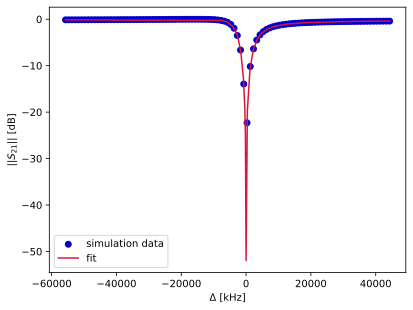

{'frequency_GHz': 8.474899672316507, 'kappa_kHz': 7029.212327300103}

In [24]:
## sorry DCM breaks for broad resonances in pypalace v0.1.3 (used in QDW), this is fixed in the latest GitHub pushes 
## so while my values below look good, yours may return nonsense -- the fit should look good, parameter estimation is just broken
resonator_params = resonator_analysis.get_resonator_parameters_driven(S21_df,show=True) # executes a DCM fit on the backend
resonator_params 

$\kappa$ would be better estimated with a finer sweep around the resonance dip. Also this fit is using depreciated code in pypalace v0.1.3, which has buggy parameter estimation. A more robust version of `resonator_analysis.get_resonator_parameters_driven()`  is available on the the pyPalace GitHub and will be released with v0.1.4 soon.